## Import libraries

In [2]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
import math
from scipy.optimize import minimize, LinearConstraint, Bounds
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import control as ct
%matplotlib widget

# Bode and Nyquist Plots

Controller: <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


s + 6
-----
  s

Plant: <TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


      1
-------------
s^2 + 2 s + 1

Open loop TF: <TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


     s + 6
---------------
s^3 + 2 s^2 + s

Error TF: <TransferFunction>: sys[7]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


   s^3 + 2 s^2 + s
---------------------
s^3 + 2 s^2 + 2 s + 6



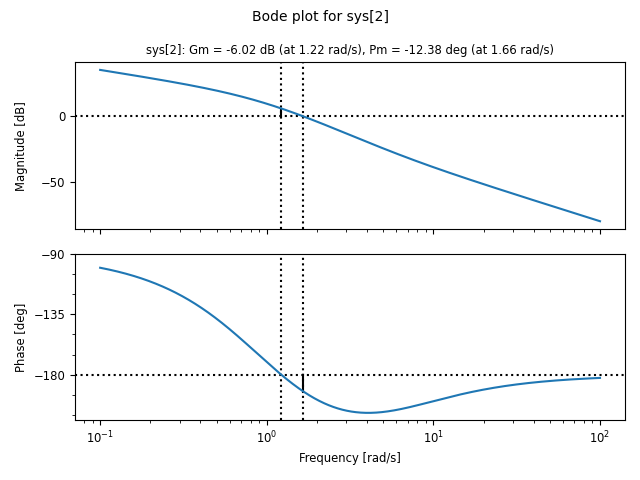

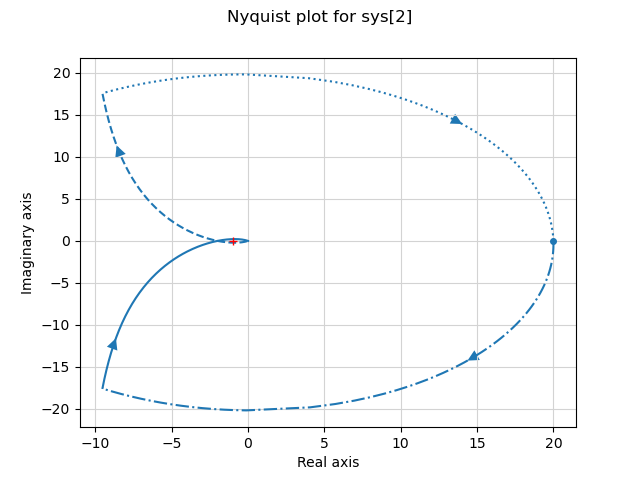

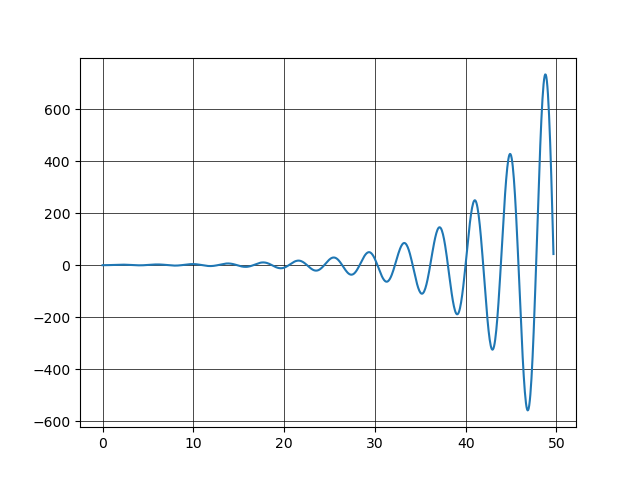

In [3]:
K           = 1
wn          = 1
xi          = 1
kp          = 1                                     # 1.0   /
ki          = 6.0                                   # 2.0   /   4.0
kd          = 00.0                                  # 10.0  /   0.0
C           = ct.tf([kd,kp,ki],[1,0])
G           = ct.tf([K*wn**2],[1,2*xi*wn,wn**2])
GOpenLoop   = C*G
Gerror      = 1/(1+C*G)
print('Controller:', C)
print('Plant:', G)
print('Open loop TF:', GOpenLoop)
print('Error TF:', Gerror)
plt.figure()
ct.bode_plot(GOpenLoop, dB = True, margins = True)    
plt.show()
plt.figure()
ct.nyquist_plot(GOpenLoop)    
plt.show()
plt.figure()
GCL     = GOpenLoop/(1 + GOpenLoop)
T, y    = ct.step_response(GCL)    
plt.plot(T,y)
plt.grid(color='k', linestyle='-', linewidth=0.5)
plt.show()

# Lead compensation

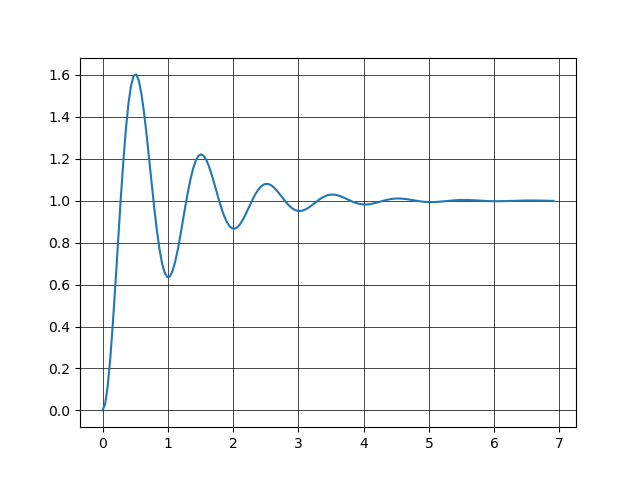

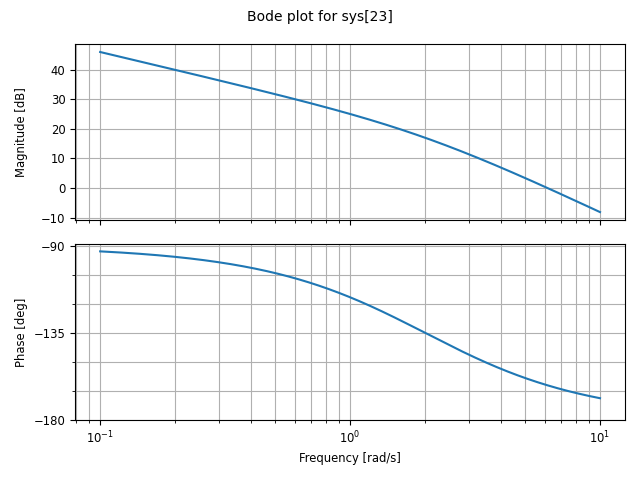

In [4]:

G       = ct.tf([4],[1,2,0])
K       = 10
G1      = K*G
plt.figure()
T, y    = ct.step_response(G1/(1+G1))    
plt.plot(T,y)
plt.grid(color='k', linestyle='-', linewidth=0.5)
plt.show()
plt.figure()
ct.bode_plot(G1, grid = True, dB = True)
plt.show()

-------------------------------------------

$\sin \phi_m = \frac{1-\alpha}{1+\alpha}$

$ C_{AP}(s) = K\frac{Ts+1}{Ts\alpha+1} $

$\omega_m = \frac{1}{\sqrt{\alpha}\,T}$

Marge de phase désirée : $50^\circ$

-------------------------------------------
### Pas à pas

- Calculer 𝐾 pour satisfaire les spécifications de régime permanent (sans prendre en compte le terme $\frac{𝑇𝑠+1}{𝑇𝑠𝛼+1}$)
- Afficher Bode pour 𝐾𝐺(𝑠)
- Déterminer l’avance de phase $\phi_m$ nécessaire (ajouter ~5 degrées)
- Calculer $\alpha= \frac{1-\sin \phi_m}{1+\sin \phi_m}$
- Calculer $\Delta\,A = \frac{1}{\sqrt{\alpha}}$ (décalage d'amplitude à cause de $\frac{𝑇𝑠+1}{𝑇𝑠𝛼+1}$) à $\omega_m$
- Déterminer $\omega_{m}$ où l'amplitude sera de 0 dB après le décalage de $\Delta A$
- Déterminer $T = \frac{1}{\omega_{m}\sqrt{\alpha}}$

-------------------------------------------

In [5]:
MP          = 180 - 162
MP_desiree  = 55
phi_m       = (MP_desiree - MP)*np.pi/180
alpha       = (1-np.sin(phi_m))/(1+np.sin(phi_m))
DeltaA      = 1/np.sqrt(alpha)
print(20*np.log10(DeltaA))
print(MP)
omega_m     = 8.8
T           = 1./(omega_m*np.sqrt(alpha))

6.045274920504848
18


alpha :  0.2485836198891456
DeltaA: 2.0056897082590197
T     : 0.22791928502943407


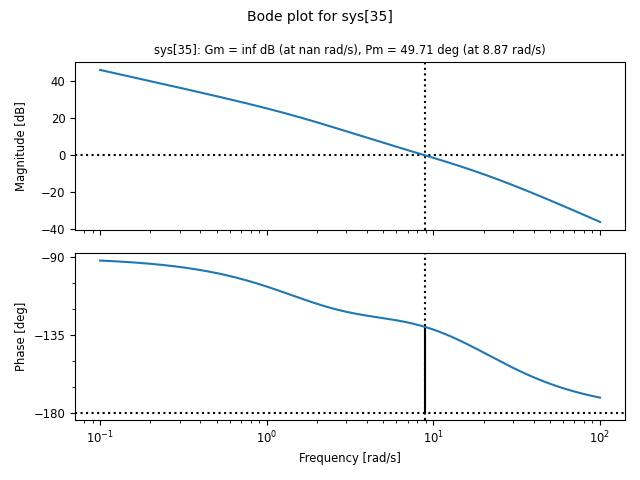

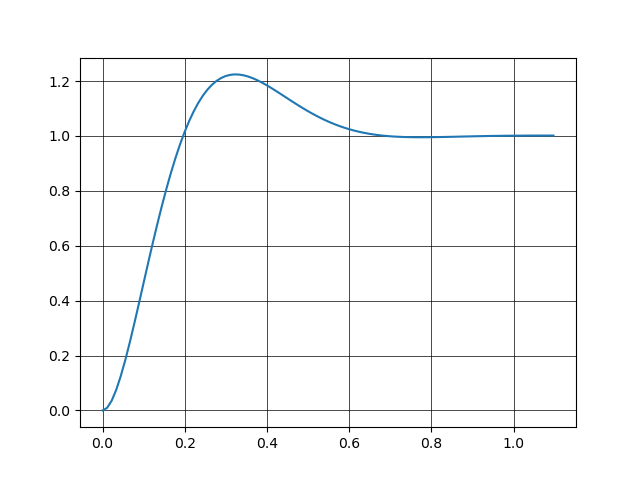

In [6]:
print('alpha : ', alpha)
print('DeltaA:', DeltaA)
print('T     :', T)
C       = K*ct.tf([T,1],[T*alpha,1])
CG      = C*G
plt.figure()
ct.bode_plot(CG, dB = True, grid = True, margins = True)    
plt.show()
plt.figure()
T, y    = ct.step_response(CG/(1+CG))    
plt.plot(T,y)
plt.grid(color='k', linestyle='-', linewidth=0.5)
plt.show()

## Answers

- For COF of $\omega_{m0} = 6.18$ rad/s, $\phi = -161.5^{\circ}\Rightarrow MP = 18.5^\circ$  <!-- 6.18, -161.5, 18.5 -->

- $50^\circ$ was requested $\Rightarrow \phi_m = 55-18.5 = 36.5^\circ \ \ (5^\circ$ added to compensate the change in $\omega_m$)  <!-- 55-18.5 = 36.5 -->

- We have $\sin \phi_m = \frac{1-\alpha}{1+\alpha}$, so $\alpha = 0.254$ <!-- 0.254 -->

- The term $\left| \frac{T\,j\omega_m + 1}{T\,\alpha\,j\,\omega_m + 1}\right|$ will add $1/\sqrt{\alpha} \rightarrow 5.95 \text{ dB}$, so <!-- 5.95 -->
    - $\omega_m = 8.8 \text{ rad/s}$, and <!-- 8.8 -->
    - $T = 1/\sqrt{\alpha}\,\omega_m = 0.225$ <!-- 0.225 -->

In [7]:
phi_m   = 35 * np.pi/180
alpha   = (1-np.sin(phi_m))/(1+np.sin(phi_m))
20*np.log10(1/np.sqrt(alpha))


5.670466483138011

In [8]:

print('alpha : ', alpha)
print('DeltaA:', DeltaA)
print('T     :', T)
C       = K*ct.tf([T,1],[T*alpha,1])
CG      = C*G
plt.figure()
ct.bode_plot(CG, dB = True, grid = True, margins = True)    
plt.show()

alpha :  0.27099005412014443
DeltaA: 2.0056897082590197
T     : [0.         0.01108239 0.02216478 0.03324717 0.04432956 0.05541195
 0.06649434 0.07757673 0.08865912 0.09974151 0.1108239  0.12190629
 0.13298867 0.14407106 0.15515345 0.16623584 0.17731823 0.18840062
 0.19948301 0.2105654  0.22164779 0.23273018 0.24381257 0.25489496
 0.26597735 0.27705974 0.28814213 0.29922452 0.31030691 0.3213893
 0.33247169 0.34355408 0.35463647 0.36571886 0.37680125 0.38788363
 0.39896602 0.41004841 0.4211308  0.43221319 0.44329558 0.45437797
 0.46546036 0.47654275 0.48762514 0.49870753 0.50978992 0.52087231
 0.5319547  0.54303709 0.55411948 0.56520187 0.57628426 0.58736665
 0.59844904 0.60953143 0.62061382 0.6316962  0.64277859 0.65386098
 0.66494337 0.67602576 0.68710815 0.69819054 0.70927293 0.72035532
 0.73143771 0.7425201  0.75360249 0.76468488 0.77576727 0.78684966
 0.79793205 0.80901444 0.82009683 0.83117922 0.84226161 0.853344
 0.86442639 0.87550878 0.88659116 0.89767355 0.90875594 0.91983833
 

TypeError: The numerator and denominator inputs must be scalars or vectors (for
SISO), or lists of lists of vectors (for SISO or MIMO).

In [ ]:
phi_m   = 37 * np.pi/180                                          # 36.5 * np.pi/180
c       = math.sin(phi_m)
alpha   = (1-c)/(1+c)
DeltaA  = 20*np.log10(1/np.sqrt(alpha))
wm      = 8.84                                          # 8.8
T       = 1/(np.sqrt(alpha)*wm)
print('alpha : ', alpha)
print('DeltaA:', DeltaA)
print('T     :', T)
C       = K*ct.tf([T,1],[T*alpha,1])
CG      = C*G
plt.figure()
ct.bode_plot(CG, dB = True, grid = True, margins = True)    
plt.show()

# Lag compensation

-------------------------------------------

$C_{RP} = K\frac{Ts + 1}{T\beta s+1}$

-------------------------------------------
### Pas à pas

- Calculer 𝐾 pour satisfaire les spécifications de régime permanent
- Afficher Bode pour 𝐾𝐺(𝑠)
- Déterminer la nouvelle crossover freq. $COF_n$ où la phase de 𝐾𝐺(𝑗𝜔)=−180°+𝑀𝑃=𝐶𝑂𝐹 (ajouter 5 ~ 12 degrées)
- Définir 1/𝑇≈𝐶𝑂𝐹/10
- Déterminer 𝛽 pour que |𝐶_𝑅𝑃 𝐺|=0 db à la 𝐶𝑂𝐹

-------------------------------------------

- Erreur de trainage = 0.2
- Marge de phase désirée = 40 deg

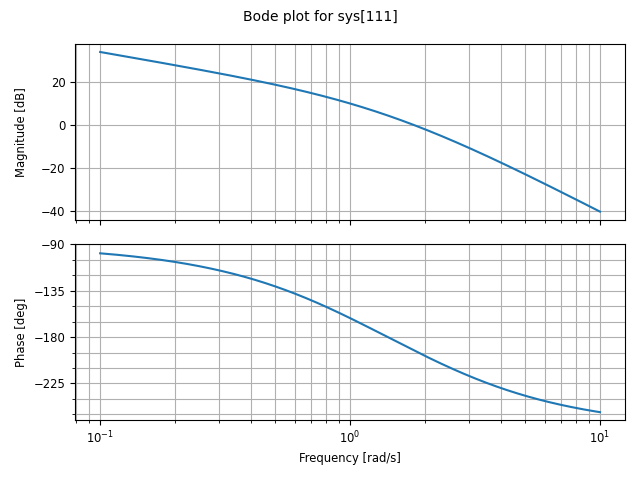

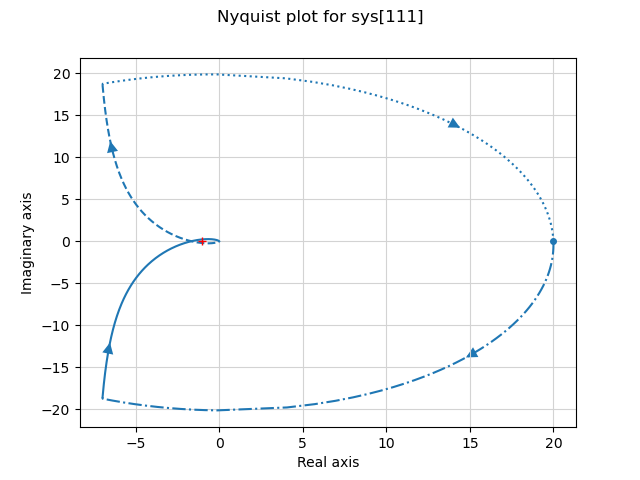

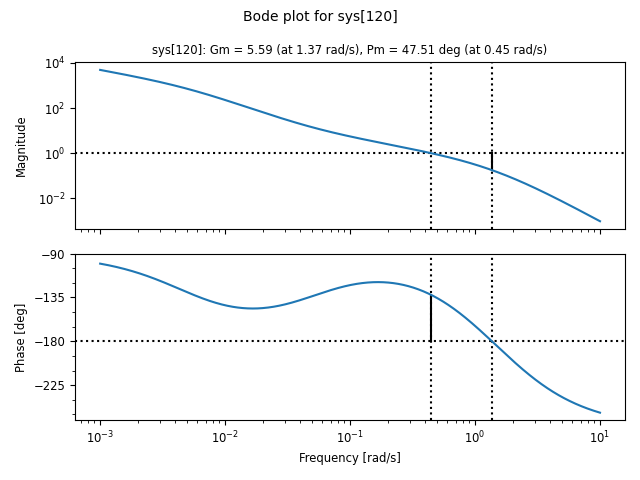

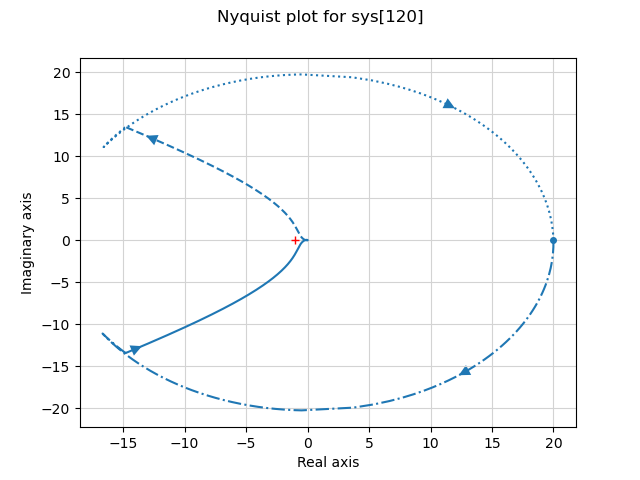

In [ ]:
s       = ct.TransferFunction.s 
G       = 1/(s*(s+1)*(0.5*s + 1))
K       = 5                                              # 5
G1      = K*G

plt.figure()
ct.bode_plot(G1,grid = True, dB = True)
plt.show()
plt.figure()
ct.nyquist_plot(G1)
plt.show()
COF_n   = 0.5               # 0.5
T       = 10/0.5            # 20
beta    = 10                # 10
C       = K*ct.tf([T,1],[T*beta,1])
CG      = C*G
plt.figure()
ct.bode_plot(CG,margins=True)
plt.show()
plt.figure()
ct.nyquist_plot(CG)
plt.show()
